# 07. Interpolative QTT Construction

## Learning goals

- understand how multiscale polynomial interpolation gives rise to low-rank QTTs
- build a QTT from only $2(N+1)$ function evaluations using `IQTT.interpolatesinglescale`
- apply the multiresolution (adaptive) construction for functions with sharp features using `IQTT.interpolateadaptive`
- use sparse local Lagrange interpolation to reduce construction cost with `IQTT.interpolatesinglescale_sparse`
- compare approximation errors and bond dimensions across all three methods

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.resolve(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia 1.12 kernel that matches the version you used for setup. The current `Manifest.toml` was resolved with Julia 1.12.5, so a Julia 1.11 kernel can fail during package loading.

In [27]:
using Tensor4all
using CairoMakie
using LaTeXStrings
import Tensor4all.QuanticsGrids as QG
import Tensor4all.QuanticsTCI as QTCI
import Tensor4all.TensorNetworks as TN
import Tensor4all.SimpleTT as STT
import Tensor4all.InterpolativeQTT as IQTT

## Background: interpolation and QTT rank

Quantized Tensor Trains (QTTs) represent a function $f:[a,b]\to\mathbb{R}$ by encoding its values on the dyadic grid $\mathcal{D}_K = \{a + (b-a)\cdot k/2^K : k=0,\ldots,2^K-1\}$ into a tensor with $K$ binary indices, then compressing it as a tensor train (MPS).

The **interpolative construction** (Lindsey 2024) provides an efficient way to build such a QTT without evaluating $f$ at all $2^K$ grid points. The key insight comes from polynomial interpolation: for $x = x_{\leq m} + x_{>m}$ (splitting the binary expansion into coarse and fine parts), we approximate

$$f(x_{\leq m} + 2^{-m}v) \approx \sum_{\alpha=0}^{N} f\!\left(x_{\leq m} + 2^{-m}c^\alpha\right) P^\alpha(v),$$

where $c^\alpha = \tfrac{\cos(\pi\alpha/N)+1}{2}$ are the **Chebyshev–Lobatto nodes** on $[0,1]$ and $P^\alpha$ are the corresponding Lagrange (cardinal) interpolating polynomials. This approximation is exact for polynomials of degree $\leq N$ and converges exponentially fast for smooth functions.

This decomposition directly bounds the rank of the $m$-th unfolding matrix of the QTT: the rank is at most $N+1$, and the approximation error decays with the Chebyshev interpolation error $E_{m,N}[f]$. For smooth functions, $E_{m,N}[f]$ decays exponentially with $N$ and also decreases with $m$ (finer scale), which is why QTT bond dimensions built this way tend to be smaller at deeper levels.

The three constructions covered in this notebook are:

| Method | Function evaluations | Construction cost | When to use |
|--------|---------------------|-------------------|-------------|
| Single-scale | $2(N+1)$ | $O(N^2 r)$ | smooth functions |
| Adaptive (multiresolution) | $\propto N \cdot K$ | $O(N^2 r K)$ | functions with localised sharp features |
| Sparse | $2(N+1)$ | $O(Nr^2)$ | large $N$, well-separated scales |

**Notation note:** In this notebook we follow the `InterpolativeQTT.jl` convention:
- `R` = QTT depth (number of binary levels; grid has $2^R$ points) — called $K$ in the Lindsey paper
- `K` or `N` = interpolation order ($N+1$ Chebyshev nodes used) — called $N$ in the Lindsey paper

## 1. Single-scale interpolation

The **basic interpolative construction** builds a QTT by first evaluating $f$ at the $2(N+1)$ points $\left\{\tfrac{\sigma + c^\alpha}{2}\right\}$ for $\sigma\in\{0,1\}$ and $\alpha = 0,\ldots,N$, storing these values in the first tensor core $A_\mathrm{L}$. All subsequent cores implement the fixed Chebyshev interpolation map and are **independent of $f$** — they only depend on the Chebyshev nodes and cardinal polynomials.

The three tensor cores from Lindsey (2024), equations (4.1)–(4.3):

$$A_\mathrm{L}^{1,\beta}(\sigma) = f\!\left(\tfrac{\sigma + c^\beta}{2}\right), \qquad A^{\alpha\beta}(\sigma) = P^\alpha\!\left(\tfrac{\sigma+c^\beta}{2}\right), \qquad A_\mathrm{R}^{\alpha,1}(\sigma) = P^\alpha\!\left(\tfrac{\sigma}{2}\right).$$

A rank-revealing QR + truncated SVD sweep is applied left-to-right during construction to expose the true numerical TT ranks, which are often much smaller than $N+1$.

`IQTT.interpolatesinglescale(f, a, b, R, K)` assembles this QTT:
- `f` — target function
- `[a, b]` — physical interval (the grid is mapped from $[0,1]$ to $[a,b]$ automatically)
- `R` — QTT depth (grid has $2^R$ points)
- `K` — interpolation order; uses $K+1$ Chebyshev–Lobatto nodes and requires only $2(K+1)$ evaluations of `f`

In [28]:
f(x) = cos(x^2) + sin(π * x)
a, b = -2.0, sqrt(2)
R = 8   # QTT depth: grid has 2^R = 256 points
K = 10  # interpolation order: uses K+1 = 11 Chebyshev nodes → only 2*(K+1) = 22 function evaluations

tt = IQTT.interpolatesinglescale(f, a, b, R, K)

grid        = QG.DiscretizedGrid{1}(R, a, b)
plotquantics = QG.grididx_to_quantics.(Ref(grid), 1:(2^R))
plotx        = QG.grididx_to_origcoord.(Ref(grid), 1:(2^R))
origdata     = f.(plotx)
ttdata       = tt.(plotquantics)

max_err = maximum(abs.(ttdata .- origdata))
println("QTT depth R=$R,  interpolation order K=$K")
println("Function evaluations used: $(2*(K+1))  (vs $(2^R) for brute force)")
println("Maximum absolute error on grid: $max_err")

QTT depth R=8,  interpolation order K=10
Function evaluations used: 22  (vs 256 for brute force)
Maximum absolute error on grid: 9.657968959242424e-6


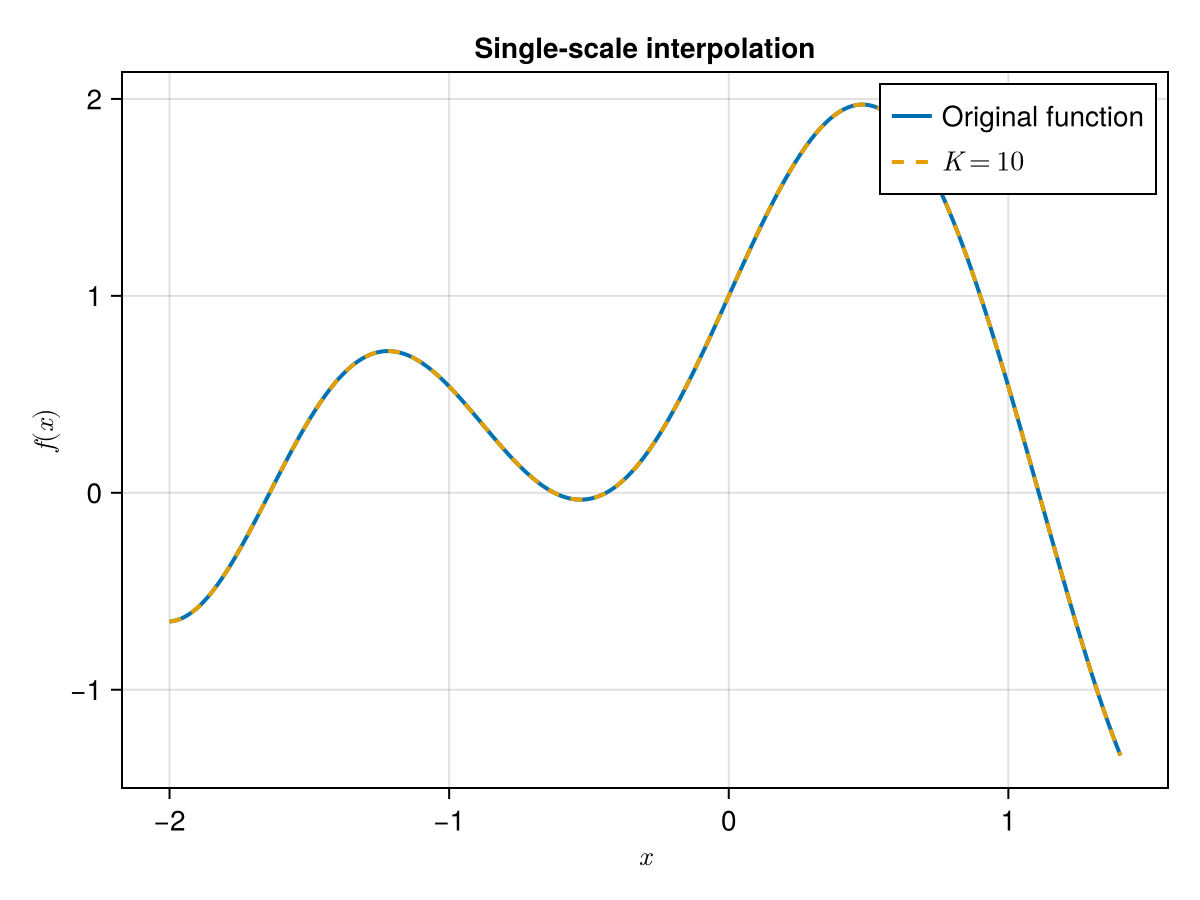

In [32]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)", title = "Single-scale interpolation")
    lines!(ax, plotx, f.(plotx), label = "Original function", linewidth = 2.0, linestyle = :solid)
    lines!(ax, plotx, ttdata, label = L"K=%$K", linewidth = 2.0, linestyle = :dash)
    axislegend(ax, pos = :best)
    fig
end

In [33]:
# Sweep over interpolation order K to see how accuracy grows with the number of Chebyshev nodes.
# Each value of K only uses 2*(K+1) function evaluations.
K_values = [4, 6, 8, 10, 12, 15, 20]
errors_K  = Float64[]

for Ki in K_values
    tti = IQTT.interpolatesinglescale(f, a, b, R, Ki)
    err = maximum(abs.(tti.(plotquantics) .- origdata))
    push!(errors_K, err)
    println("K=$Ki  ($(2*(Ki+1)) evals)  →  max err = $err")
end

K=4  (10 evals)  →  max err = 0.12005524174184706
K=6  (14 evals)  →  max err = 0.011703772903765786
K=8  (18 evals)  →  max err = 0.00048275702620192984
K=10  (22 evals)  →  max err = 9.657968959242424e-6
K=12  (26 evals)  →  max err = 9.307955098902809e-7
K=15  (32 evals)  →  max err = 4.9536720836407255e-9
K=20  (42 evals)  →  max err = 4.426015109970649e-12


In [ ]:
let
    fig = Figure(size = (600, 360))
    ax = Axis(fig[1, 1], xlabel = "interpolation order K", ylabel = "max absolute error",
              title = "Accuracy vs K  (single-scale,  R=$R)",
              yscale = log10)
    scatterlines!(ax, K_values, errors_K, linewidth = 2, color = :deepskyblue4, markersize = 8)
    fig
end

The error drops exponentially with $K$, reaching machine precision around $K=10$ for this function. The total number of function evaluations is only $2(K+1)$, compared to $2^R = 256$ for a brute-force grid evaluation — a saving of more than an order of magnitude even at modest $K$.

This exponential convergence is the payoff of Chebyshev interpolation: for a function analytic on the interval, the interpolation error decays as $\rho^{-N}$ where $\rho > 1$ is the size of the largest Bernstein ellipse to which the function extends analytically (Proposition 5 of Lindsey 2024).

## 2. Adaptive (multiresolution) interpolation

The single-scale construction works well for globally smooth functions, but struggles when the function has **localised sharp features** (large derivatives concentrated in a small region). A narrow Gaussian

$$f(x) = \exp\!\left(-\tfrac{1}{2}(x/\alpha)^2\right), \quad \alpha \ll 1,$$

is a classic example. As $\alpha\to 0$ the function becomes smoother away from $x=0$ but increasingly sharp near the origin. A bound based on Fourier series is not uniform in $\alpha$, yet empirically the QTT rank stays bounded. The multiresolution construction clarifies why.

**The idea:** mark certain dyadic subintervals as "dangerous" — those that straddle the sharp feature. Inside these intervals, defer Chebyshev interpolation to the next finer scale rather than interpolating from the current coarse grid. The construction ensures that interpolation is only ever attempted on **safe** intervals where the function is smooth, so $N$ Chebyshev nodes are sufficient everywhere.

Formally, the tensor core at level $k$ is augmented with extra rows that track whether we are inside a dangerous interval (Theorem 20, Lindsey 2024). The key error bound is

$$\|S - T\|_\infty \leq \max\bigl\{E_{I,N}[f] : I \text{ is a safe dyadic subinterval}\bigr\},$$

and since $f$ is smooth on all safe intervals, this error can be controlled by $N$ alone — **independently of how sharp the feature is**.

For the Gaussian, the dangerous subintervals at level $k$ are $[0, 2^{-k}]$, which shrink towards the peak. The safe subintervals $[2^{-k}, 2^{1-k}]$ are smooth, and the worst interpolation error occurs at $k=1$ (widest safe interval).

`IQTT.interpolateadaptive(f, a, b, R, K)` applies this adaptive strategy automatically. The function evaluations are still embarrassingly parallel.

In [34]:
α = 0.01  # small α → very sharp Gaussian centred at x=0
f(x) = exp(-0.5 * (x / α)^2)
a, b = 0.0, 1.0
R = 8   # QTT depth
K = 18  # interpolation order — N=18 gives machine precision for this Gaussian (cf. Fig. 8.5 of Lindsey 2024)

tt_single   = IQTT.interpolatesinglescale(f, a, b, R, K)
tt_adaptive = IQTT.interpolateadaptive(f, a, b, R, K)

grid         = QG.DiscretizedGrid{1}(R, a, b)
plotquantics = QG.grididx_to_quantics.(Ref(grid), 1:(2^R))
plotx        = QG.grididx_to_origcoord.(Ref(grid), 1:(2^R))
origdata     = f.(plotx)

err_single   = maximum(abs.(tt_single.(plotquantics)   .- origdata))
err_adaptive = maximum(abs.(tt_adaptive.(plotquantics) .- origdata))

println("α = $α,  R=$R,  K=$K")
println("Single-scale max error:   $err_single")
println("Adaptive max error:       $err_adaptive")

α = 0.01,  R=8,  K=18
Single-scale max error:   0.021968734914486476
Adaptive max error:       6.1102234383270115e-12


In [36]:
let
    fig = Figure(size = (900, 360))

    ax1 = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",
               title = L"Narrow Gaussian $\alpha=%$α$:  single-scale vs adaptive QTT")
    lines!(ax1, plotx, origdata,                        label = "exact",        linewidth = 2, color = :black)
    lines!(ax1, plotx, tt_single.(plotquantics),        label = "single-scale", linewidth = 2, color = :goldenrod2,   linestyle = :dash)
    lines!(ax1, plotx, tt_adaptive.(plotquantics),      label = "adaptive",     linewidth = 2, color = :deepskyblue4, linestyle = :dot)
    axislegend(ax1, position = :topright)

    ax2 = Axis(fig[1, 2], xlabel = L"x", ylabel = "absolute error",
               title = "Pointwise error  (log scale)", yscale = log10)
    lines!(ax2, plotx, max.(abs.(tt_single.(plotquantics)   .- origdata), 1e-17), label = "single-scale", linewidth = 2, color = :goldenrod2)
    lines!(ax2, plotx, max.(abs.(tt_adaptive.(plotquantics) .- origdata), 1e-17), label = "adaptive",     linewidth = 2, color = :deepskyblue4)
    axislegend(ax2, position = :best)

    fig
end

ArgumentError: ArgumentError: Position symbol must have length == 2

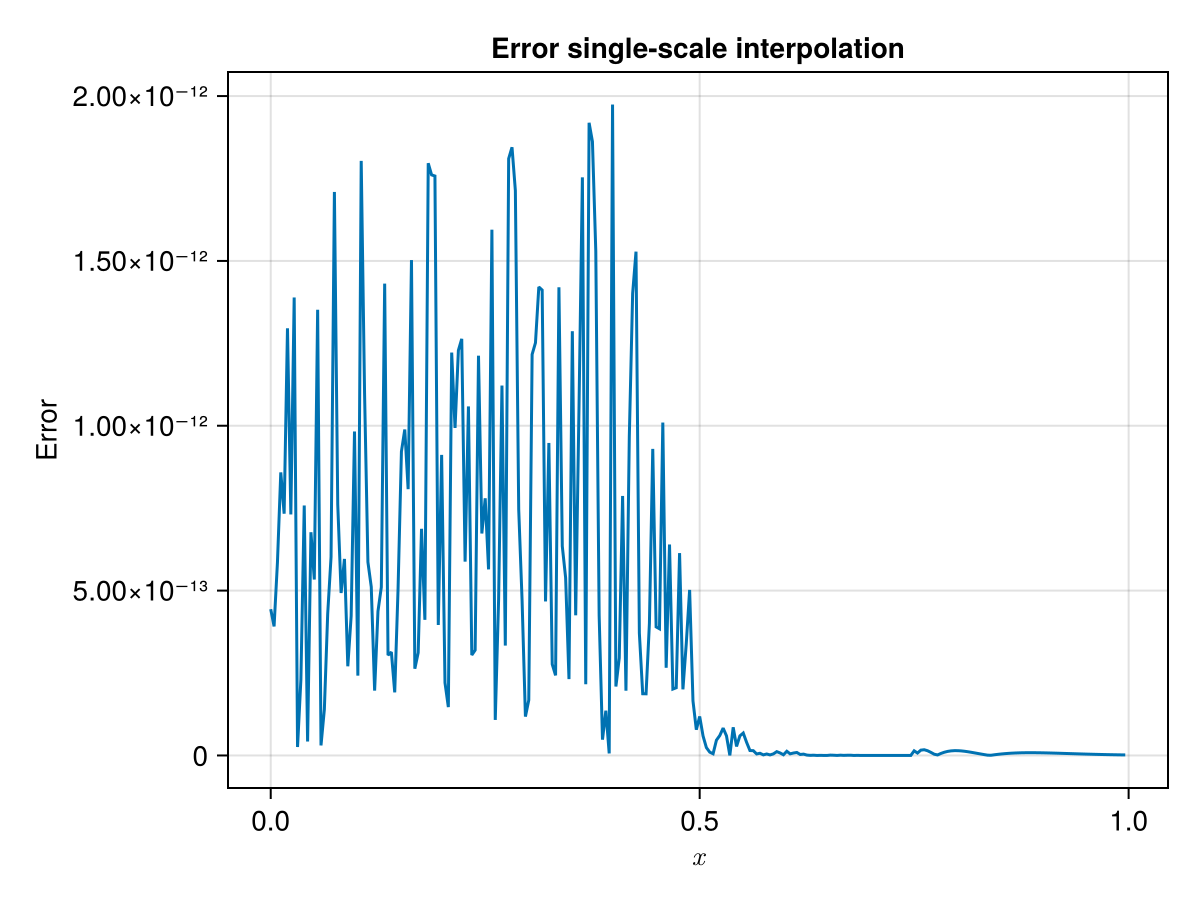

In [20]:
# Sweep over α to confirm that the adaptive construction maintains bounded error
# even as the Gaussian becomes arbitrarily narrow (Figure 8.5 of Lindsey 2024).
α_values         = [1.0, 0.1, 0.01, 0.001, 0.0001]
errs_single_α    = Float64[]
errs_adaptive_α  = Float64[]

for αi in α_values
    fi(x)  = exp(-0.5 * (x / αi)^2)
    grid_i = QG.DiscretizedGrid{1}(R, 0.0, 1.0)
    qi     = QG.grididx_to_quantics.(Ref(grid_i), 1:(2^R))
    xi     = QG.grididx_to_origcoord.(Ref(grid_i), 1:(2^R))
    ori    = fi.(xi)
    push!(errs_single_α,   maximum(abs.(IQTT.interpolatesinglescale(fi, 0.0, 1.0, R, K).(qi)  .- ori)))
    push!(errs_adaptive_α, maximum(abs.(IQTT.interpolateadaptive(fi, 0.0, 1.0, R, K).(qi)     .- ori)))
end

let
    fig = Figure(size = (620, 380))
    ax = Axis(fig[1, 1], xlabel = L"\alpha", ylabel = "max absolute error",
              title = "Error vs Gaussian width  (R=$R, K=$K)",
              xscale = log10, yscale = log10)
    scatterlines!(ax, α_values, errs_single_α,   label = "single-scale", linewidth = 2, color = :goldenrod2)
    scatterlines!(ax, α_values, errs_adaptive_α, label = "adaptive",     linewidth = 2, color = :deepskyblue4)
    axislegend(ax, position = :best)
    fig
end

The adaptive construction keeps the error bounded across all values of $\alpha$, confirming the theory. The single-scale construction degrades as $\alpha$ shrinks because the global interpolation order $K$ is no longer sufficient to resolve the increasingly sharp peak from the coarse top-level Chebyshev grid. The adaptive construction sidesteps this by deferring interpolation inside the dangerous interval $[0, 2^{-k}]$ at each scale, so it never attempts a single-level interpolation across the peak.

## 3. Sparse interpolation

When the interpolation order $N$ is large (many Chebyshev nodes needed to resolve the function), the rank-revealing construction becomes expensive: each left-to-right SVD step contracts a dense $(N+1)\times(N+1)$ matrix, giving $O(N^2 r)$ cost per level.

The **sparse construction** (Section 4.3 of Lindsey 2024, following Boyd 1992) replaces the dense Chebyshev cardinal functions $P^\alpha$ with a **local Lagrange interpolation** in the angular coordinate $\theta = \arccos(2x-1)$. For each output point, only the nearest $2M+1$ Chebyshev nodes (in $\theta$-space) are used, so each column of the interpolating core $\tilde{A}(\sigma)$ has $O(M)$ nonzero entries. The construction cost drops to $O(Nr^2)$.

The bandwidth $M$ controls the accuracy–speed trade-off:
- Small $M$ (e.g. 5–10): fast construction; converges as $N\to\infty$ for fixed $M$, but requires larger $N$ to compensate
- Large $M$ (close to $N$): approaches the dense construction; high accuracy at smaller $N$

The convergence in $N$ for fixed $M$ is exponential in $M$, so even modest $M$ can reach machine precision for large enough $N$.

This is particularly useful for peaked functions like the Lorentzian

$$f(x) = \frac{\alpha}{\sqrt{\alpha^2 + (x-\tfrac{1}{2})^2}}, \quad \alpha \ll 1,$$

where the required $N$ scales as $N\sim C/\sqrt{\alpha}$ to maintain fixed accuracy (Section 8.2 of Lindsey 2024).

`IQTT.interpolatesinglescale_sparse(f, a, b, R, N, M)` adds the bandwidth `M` to the dense signature.

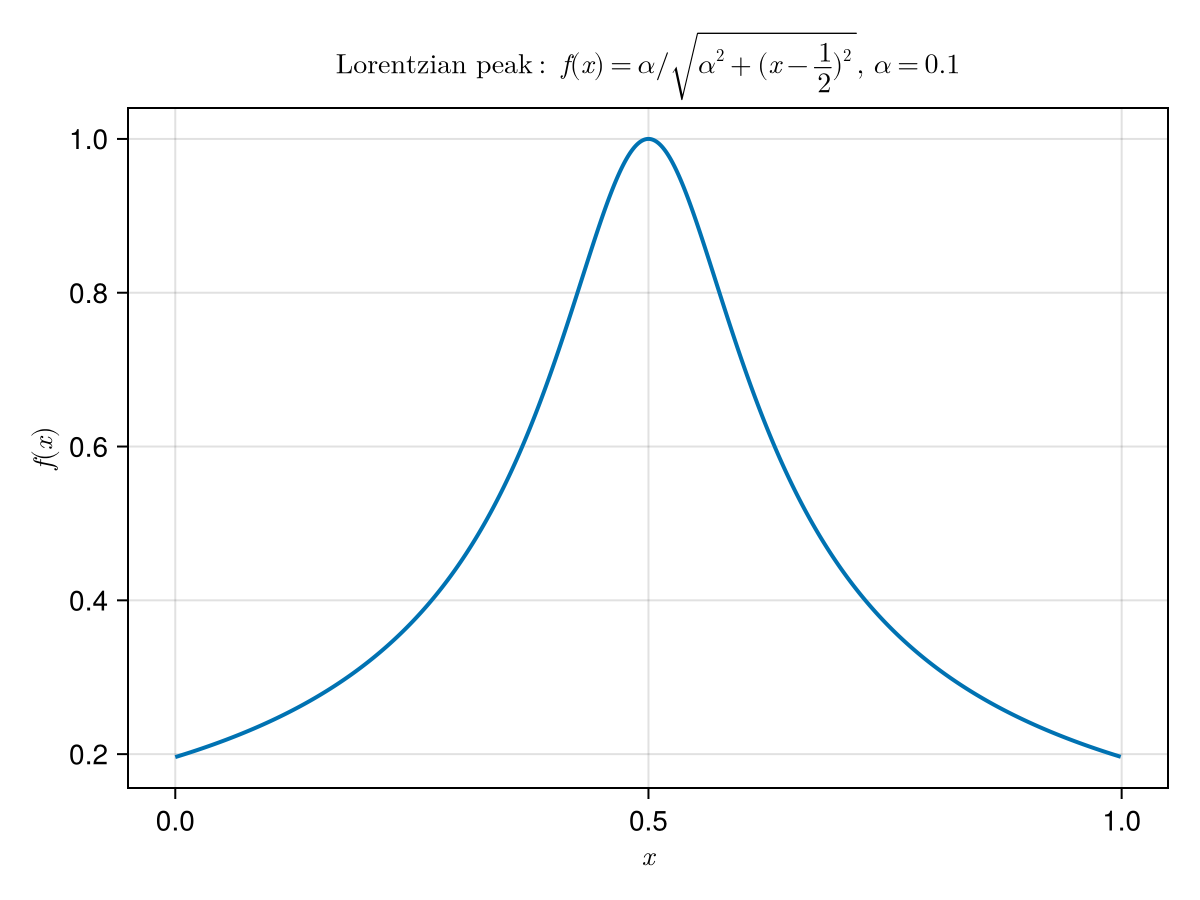

In [21]:
α = 0.1
f(x) = α / sqrt(α^2 + (x - 0.5)^2)
a, b = 0.0, 1.0
R = 10    # QTT depth: 2^10 = 1024 grid points
N_dense  = 100   # dense construction interpolation order
N_sparse = 200   # sparse construction interpolation order (larger N, sparse cores stay cheap)

grid         = QG.DiscretizedGrid{1}(R, a, b)
quanticsinds = QG.grididx_to_quantics.(Ref(grid), 1:(2^R))
plotx        = QG.grididx_to_origcoord.(Ref(grid), 1:(2^R))
origdata     = f.(plotx)

tt_dense  = IQTT.interpolatesinglescale(f, a, b, R, N_dense)
err_dense = maximum(abs.(tt_dense.(quanticsinds) .- origdata))
println("Dense  N=$N_dense:  max err = $err_dense")

M_values    = [5, 10, 15, 20, 30]
tt_sparse   = [IQTT.interpolatesinglescale_sparse(f, a, b, R, N_sparse, M) for M in M_values]
errs_sparse = [maximum(abs.(tt.(quanticsinds) .- origdata)) for tt in tt_sparse]

for (M, err) in zip(M_values, errs_sparse)
    println("Sparse N=$N_sparse M=$M:  max err = $err")
end

let
    fig = Figure(size = (900, 360))
    ax1 = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",
               title = L"Lorentzian peak: $f(x) = \alpha\,/\sqrt{\alpha^2+(x-\frac{1}{2})^2}$,  $\alpha=%$α$")
    lines!(ax1, plotx, origdata, linewidth = 2)

    ax2 = Axis(fig[1, 2], xlabel = L"M \text{ (bandwidth)}", ylabel = "max absolute error",
               title = "Sparse error vs M  (N=$N_sparse,  dense N=$N_dense shown dashed)",
               yscale = log10)
    scatterlines!(ax2, M_values, errs_sparse, label = "sparse  N=$N_sparse", linewidth = 2, color = :deepskyblue4)
    hlines!(ax2, [err_dense], color = :black, linestyle = :dash, label = "dense  N=$N_dense")
    axislegend(ax2, position = :topright)
    fig
end

In [ ]:
# Sweep N for fixed M to confirm that the sparse construction converges as N grows.
M_fixed  = 10
N_values = [50, 100, 200, 500, 1000]
errs_N   = Float64[]

for Ni in N_values
    tt_i = IQTT.interpolatesinglescale_sparse(f, a, b, R, Ni, M_fixed)
    push!(errs_N, maximum(abs.(tt_i.(quanticsinds) .- origdata)))
end

let
    fig = Figure(size = (600, 380))
    ax = Axis(fig[1, 1], xlabel = "interpolation order N", ylabel = "max absolute error",
              title = "Sparse convergence in N  (M=$M_fixed,  R=$R)",
              yscale = log10)
    scatterlines!(ax, N_values, errs_N, linewidth = 2, color = :deepskyblue4, markersize = 8,
                  label = "sparse  M=$M_fixed")
    hlines!(ax, [err_dense], color = :black, linestyle = :dash, label = "dense  N=$N_dense")
    axislegend(ax, position = :topright)
    fig
end

For fixed $M$, the sparse construction converges to the same accuracy as the dense construction as $N$ grows. The convergence is exponential in $M$: at $M=10$, the sparse result with $N=1000$ can match or beat the dense result with $N=100$, while the sparse construction only requires $O(Nr^2)$ work rather than $O(N^2 r)$.

The practical advantage is most visible for peaked functions where $N$ must be large to resolve the feature. In the paper (Figure 8.3) each construction for $N$ up to 10000 was completed in under 0.5 seconds, which would not be feasible with the dense $O(N^3)$ compression approach.

## What to notice

- The interpolative construction builds a QTT using only $2(N+1)$ function evaluations, regardless of the QTT depth $R$. This is the key advantage over TCI, which requires $O(2^R)$ evaluations in the worst case. All evaluations are **embarrassingly parallel**.
- `IQTT.interpolatesinglescale` uses a dense Chebyshev-Lobatto grid and a rank-revealing left-to-right SVD sweep. The resulting QTT has ranks that tend to decay towards deeper levels (finer scales) for smooth functions, as predicted by the theory (Propositions 2 and 5 of Lindsey 2024).
- The exponential convergence in $K$ (interpolation order) is the hallmark of Chebyshev interpolation for analytic or highly differentiable functions. Smooth functions typically hit machine precision at modest $K$ (10–20).
- `IQTT.interpolateadaptive` maintains bounded error for functions with sharp features by deferring Chebyshev interpolation inside "dangerous" dyadic subintervals. The error bound is independent of how sharp the feature is.
- `IQTT.interpolatesinglescale_sparse` allows large $N$ to be used efficiently. The bandwidth $M$ is a second tuning parameter: larger $M$ gives higher accuracy at the cost of denser core matrices.
- The interpolative QTT approach and TCI are **complementary**: TCI is more general (works for arbitrary tensor trains, not just QTTs) but can fail for highly oscillatory functions, while the interpolative approach is restricted to QTTs but is always stable and uses far fewer evaluations.

**Reference:** M. Lindsey, *Multiscale interpolative construction of quantized tensor trains*, arXiv:2311.12554 (2024).

## API recap

- `Tensor4all.InterpolativeQTT.interpolatesinglescale(f, a, b, R, K)` — dense single-scale QTT; uses $2(K+1)$ evaluations of `f`
- `Tensor4all.InterpolativeQTT.interpolateadaptive(f, a, b, R, K)` — multiresolution (adaptive) QTT; handles functions with sharp features near $x=a$
- `Tensor4all.InterpolativeQTT.interpolatesinglescale_sparse(f, a, b, R, N, M)` — sparse single-scale QTT with local-Lagrange bandwidth `M`; same evaluations as dense but $O(Nr^2)$ cost
- `Tensor4all.QuanticsGrids.DiscretizedGrid{1}` — 1D quantics grid with $2^R$ points on $[a,b]$
- `Tensor4all.QuanticsGrids.grididx_to_quantics` — integer grid index → binary quantics index tuple
- `Tensor4all.QuanticsGrids.grididx_to_origcoord` — integer grid index → physical coordinate